Starting with looking at our data

📂 Train Set Distribution:
clear: 37344
foggy: 130
overcast: 8770
partly cloudy: 4881
rainy: 5070
snowy: 5549
unknown: 8119

📂 Validation Set Distribution:
clear: 5346
foggy: 13
overcast: 1239
partly cloudy: 738
rainy: 738
snowy: 769
unknown: 1157


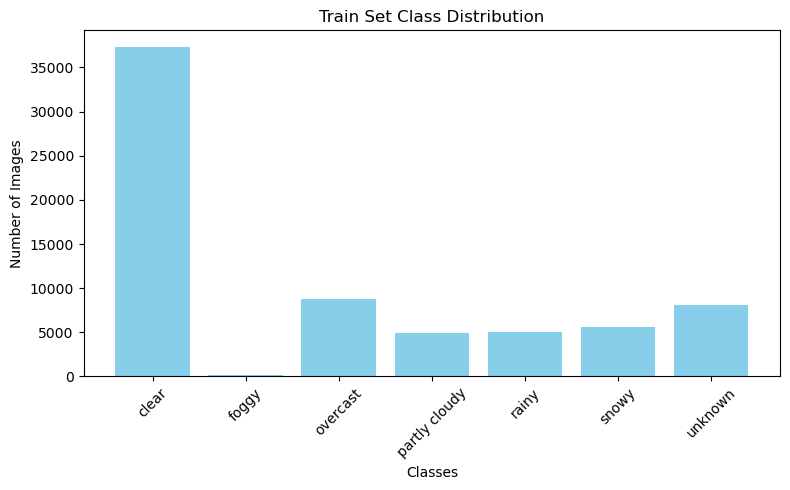

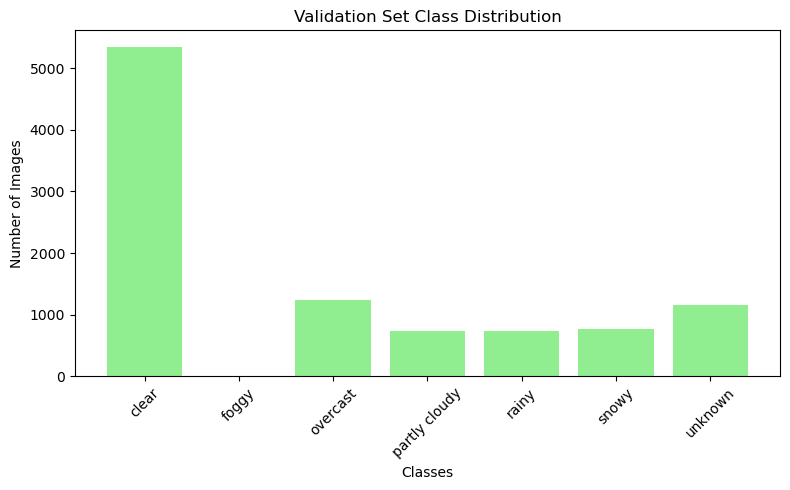

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt

def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
            class_counts[class_name] = num_images
    return class_counts

def plot_class_distribution(counts_dict, title, color):
    classes = list(counts_dict.keys())
    counts = list(counts_dict.values())

    plt.figure(figsize=(8, 5))
    plt.bar(classes, counts, color=color)
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


base_path ="F:/UNI/masters/machine_learning/project" 
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")

# Count and plot
train_counts = count_images_per_class(train_path)
val_counts = count_images_per_class(val_path)

print("📂 Train Set Distribution:")
for cls, count in sorted(train_counts.items()):
    print(f"{cls}: {count}")

print("\n📂 Validation Set Distribution:")
for cls, count in sorted(val_counts.items()):
    print(f"{cls}: {count}")

plot_class_distribution(train_counts, "Train Set Class Distribution", "skyblue")
plot_class_distribution(val_counts, "Validation Set Class Distribution", "lightgreen")

Moving onto B_1.a with Statistic description of the data.
- we calclutate the statistics for each image inside the train and validation
- analyzing the class distribution and class imbalance
- checking for outliers

In [2]:

from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 🧠 Extract 21 statistics using PIL (resized)
def extract_image_stats_pil(img_path):
    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((128, 128))  # Resize to speed up
            img_array = np.array(img, dtype=np.float32)

            means = np.mean(img_array, axis=(0, 1))
            stds = np.std(img_array, axis=(0, 1))
            mins = np.min(img_array, axis=(0, 1))
            maxs = np.max(img_array, axis=(0, 1))
            medians = np.median(img_array, axis=(0, 1))
            q25 = np.percentile(img_array, 25, axis=(0, 1))
            q75 = np.percentile(img_array, 75, axis=(0, 1))

            return np.array([
                means[0], means[1], means[2],
                stds[0], stds[1], stds[2],
                mins[0], mins[1], mins[2],
                maxs[0], maxs[1], maxs[2],
                medians[0], medians[1], medians[2],
                q25[0], q25[1], q25[2],
                q75[0], q75[1], q75[2],
            ])
    except Exception as e:
        print(f"⚠️ Error processing {img_path}: {e}")
        return None

# 🔁 Category-wise fast processing with PIL
def compute_pil_category_profiles(base_path, subfolders=['train', 'val'], max_images_per_class=None):
    category_profiles = {}
    feature_count = 21

    for split in subfolders:
        split_path = os.path.join(base_path, split)
        for category in tqdm(os.listdir(split_path), desc=f"{split} categories"):
            category_path = os.path.join(split_path, category)
            if not os.path.isdir(category_path):
                continue

            image_files = [
                os.path.join(category_path, f)
                for f in os.listdir(category_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            if max_images_per_class:
                image_files = image_files[:max_images_per_class]

            # Parallel loading
            with ThreadPoolExecutor(max_workers=8) as executor:
                results = list(tqdm(
                    executor.map(extract_image_stats_pil, image_files),
                    total=len(image_files),
                    desc=f"{split}/{category}",
                    leave=False
                ))

            vectors = [r for r in results if r is not None]
            if vectors:
                mean_vector = np.mean(vectors, axis=0)
                category_profiles[category] = mean_vector

    # Final formatting
    feature_names = [
        'mean_R', 'mean_G', 'mean_B',
        'std_R', 'std_G', 'std_B',
        'min_R', 'min_G', 'min_B',
        'max_R', 'max_G', 'max_B',
        'median_R', 'median_G', 'median_B',
        'q25_R', 'q25_G', 'q25_B',
        'q75_R', 'q75_G', 'q75_B'
    ]
    rows = []
    for category, vector in category_profiles.items():
        record = dict(zip(feature_names, vector))
        record['category'] = category
        rows.append(record)

    return pd.DataFrame(rows)

# 🧭 Your dataset path
  # Update this if needed

# 🚀 Run the PIL-optimized version
df_profiles = compute_pil_category_profiles(base_path)
df_profiles.to_csv("category_profiles.csv", index=False)
print("✅ Finished! Saved to 'category_profiles.csv'")


val/foggy:   0%|                                                                                | 0/13 [00:00<?, ?it/s]
                                                                                                                       
val categories: 100%|████████████████████████████████████████████████████████████████████| 7/7 [00:32<00:00,  4.65s/it]

✅ Finished! Saved to 'category_profiles.csv'


Class distribution and class imbalance  look bellow

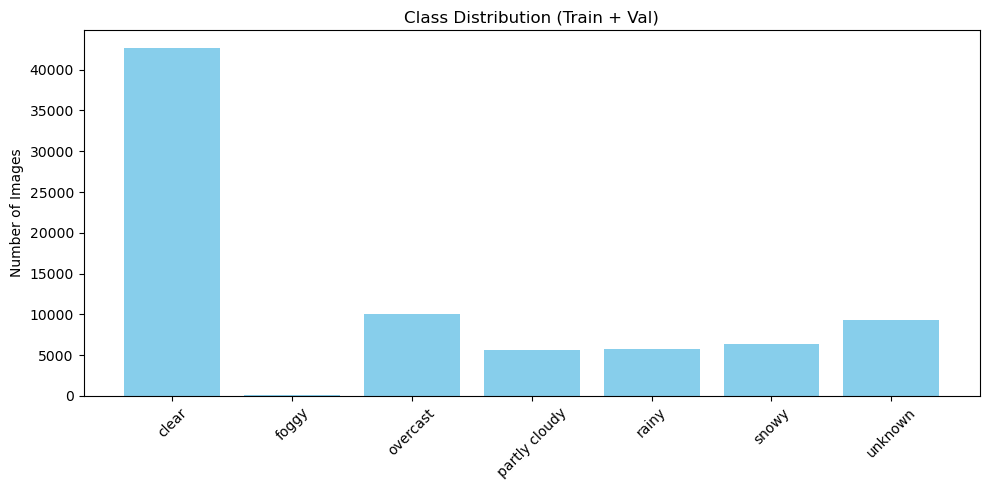

In [6]:
# class distribution
import os
import matplotlib.pyplot as plt

def count_images_per_class(dataset_path, subfolders=['train', 'val']):
    class_counts = {}

    for split in subfolders:
        split_path = os.path.join(dataset_path, split)
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                count = len([
                    f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ])
                class_counts[class_name] = class_counts.get(class_name, 0) + count
    return class_counts

# 🔧 Set path
dataset_path = "F:/UNI/masters/machine_learning/project"   # Update if needed
counts = count_images_per_class(dataset_path)

# 📊 Plot
plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="skyblue")
plt.title("Class Distribution (Train + Val)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

outliers detection

In [19]:
import os
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def extract_image_stats_full(img_path, label, split):
    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((128, 128))
            img_array = np.array(img, dtype=np.float32)

            means = np.mean(img_array, axis=(0, 1))
            stds = np.std(img_array, axis=(0, 1))
            mins = np.min(img_array, axis=(0, 1))
            maxs = np.max(img_array, axis=(0, 1))
            medians = np.median(img_array, axis=(0, 1))
            q25 = np.percentile(img_array, 25, axis=(0, 1))
            q75 = np.percentile(img_array, 75, axis=(0, 1))

            return {
                'mean_R': means[0], 'mean_G': means[1], 'mean_B': means[2],
                'std_R': stds[0], 'std_G': stds[1], 'std_B': stds[2],
                'min_R': mins[0], 'min_G': mins[1], 'min_B': mins[2],
                'max_R': maxs[0], 'max_G': maxs[1], 'max_B': maxs[2],
                'median_R': medians[0], 'median_G': medians[1], 'median_B': medians[2],
                'q25_R': q25[0], 'q25_G': q25[1], 'q25_B': q25[2],
                'q75_R': q75[0], 'q75_G': q75[1], 'q75_B': q75[2],
                'label': label,
                'split': split,
                'filename': os.path.basename(img_path)
            }
    except Exception as e:
        print(f"⚠️ Error processing {img_path}: {e}")
        return None

def generate_image_statistics(base_path="F:/UNI/masters/machine_learning/project", subfolders=['train', 'val'], max_images_per_class=None):
    data = []
    for split in subfolders:
        split_path = os.path.join(base_path, split)
        for label in tqdm(os.listdir(split_path), desc=f"Processing {split}"):
            label_path = os.path.join(split_path, label)
            if not os.path.isdir(label_path):
                continue

            image_files = [
                os.path.join(label_path, f)
                for f in os.listdir(label_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]
            if max_images_per_class:
                image_files = image_files[:max_images_per_class]

            # Process with multithreading
            with ThreadPoolExecutor(max_workers=8) as executor:
                results = list(tqdm(
                    executor.map(lambda p: extract_image_stats_full(p, label, split), image_files),
                    total=len(image_files),
                    desc=f"{split}/{label}",
                    leave=False
                ))

            # Append only valid results
            data.extend([res for res in results if res is not None])

    df = pd.DataFrame(data)
    df.to_csv("image_statistics2.csv", index=False)
    print("✅ Saved to image_statistics.csv")
    return df


In [ ]:
df = generate_image_statistics()

end of b1 .a onto the next task 

In [24]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean

# Load full image data and category profiles
df_images = pd.read_csv("image_statistics2.csv")
df_profiles = pd.read_csv("category_profiles.csv")

# Drop NaNs just in case
df_images.dropna(inplace=True)

# Feature columns (all 21)
feature_cols = [col for col in df_images.columns if col.startswith(("mean", "std", "min", "max", "median", "q25", "q75"))]

# Merge category profile into each image
def compute_distance(row, category_vectors):
    category = row["label"]
    if category not in category_vectors:
        return np.nan
    profile_vector = category_vectors[category]
    image_vector = row[feature_cols].values
    return euclidean(image_vector, profile_vector)

# Prepare dict of centroids
category_vectors = {
    row["category"]: row[feature_cols].values
    for _, row in df_profiles.iterrows()
}

# Compute distance from centroid
df_images["distance_to_centroid"] = df_images.apply(
    lambda row: compute_distance(row, category_vectors), axis=1
)

# Flag top 5% as outliers (or use z-score if you prefer)
threshold = df_images["distance_to_centroid"].quantile(0.95)
df_images["is_outlier"] = df_images["distance_to_centroid"] > threshold

# 🔍 Summary
n_outliers = df_images["is_outlier"].sum()
print(f"⚠️ Detected {n_outliers} outliers out of {len(df_images)} images")

# 💾 Save results
df_images.to_csv("image_statistics_with_outliers.csv", index=False)
print("✅ Saved labeled results to 'image_statistics_with_outliers.csv'")


⚠️ Detected 3994 outliers out of 79863 images
✅ Saved labeled results to 'image_statistics_with_outliers.csv'


In [25]:
import pandas as pd

# Load the image statistics with outlier flags
df = pd.read_csv("image_statistics_with_outliers.csv")

# Drop any incomplete rows
df.dropna(inplace=True)

# Filter out the outliers
df_filtered = df[df["is_outlier"] == False]

# Define the 21 feature columns
feature_cols = [col for col in df.columns if col.startswith(("mean", "std", "min", "max", "median", "q25", "q75"))]

# Group by category (label) and compute mean feature vector
df_category_profiles = df_filtered.groupby("label")[feature_cols].mean().reset_index()

# Rename 'label' to 'category' for consistency
df_category_profiles.rename(columns={"label": "category"}, inplace=True)

# Save to CSV
df_category_profiles.to_csv("category_profiles_no_outliers.csv", index=False)
print("✅ Done! Saved to 'category_profiles_no_outliers.csv'")

✅ Done! Saved to 'category_profiles_no_outliers.csv'


In [26]:
import pandas as pd

# Load full dataset with outlier info
df = pd.read_csv("image_statistics_with_outliers.csv")

# Drop NaN values just in case
df.dropna(inplace=True)

# Keep only non-outliers
df_clean = df[df["is_outlier"] == False].copy()

# (Optional) Drop helper columns
df_clean.drop(columns=["is_outlier", "distance_to_centroid"], inplace=True)

# Save as a clean version
df_clean.to_csv("image_statistics_clean.csv", index=False)
print("✅ Cleaned dataset saved to 'image_statistics_clean.csv'")

✅ Cleaned dataset saved to 'image_statistics_clean.csv'


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Load image statistics
df = pd.read_csv("image_statistics2.csv")

# Drop NaNs just in case
df.dropna(inplace=True)

# Feature columns (21)
feature_cols = [col for col in df.columns if col.startswith(("mean", "std", "min", "max", "median", "q25", "q75"))]

# Compute z-scores per feature
z_scores = np.abs(zscore(df[feature_cols]))

# Flag as outlier if any feature z-score > 3
df["is_outlier"] = (z_scores > 3).any(axis=1)

# Save new file with outlier flags
df.to_csv("image_statistics_with_outliers_zscore.csv", index=False)
print("✅ Saved outlier detection using z-score to 'image_statistics_with_outliers_zscore.csv'")
print(f"⚠️ Total outliers detected: {df['is_outlier'].sum()}")


✅ Saved outlier detection using z-score to 'image_statistics_with_outliers_zscore.csv'
⚠️ Total outliers detected: 5346


C:\Users\panos\AppData\Local\Temp\ipykernel_9428\558271741.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
Z:\programms\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


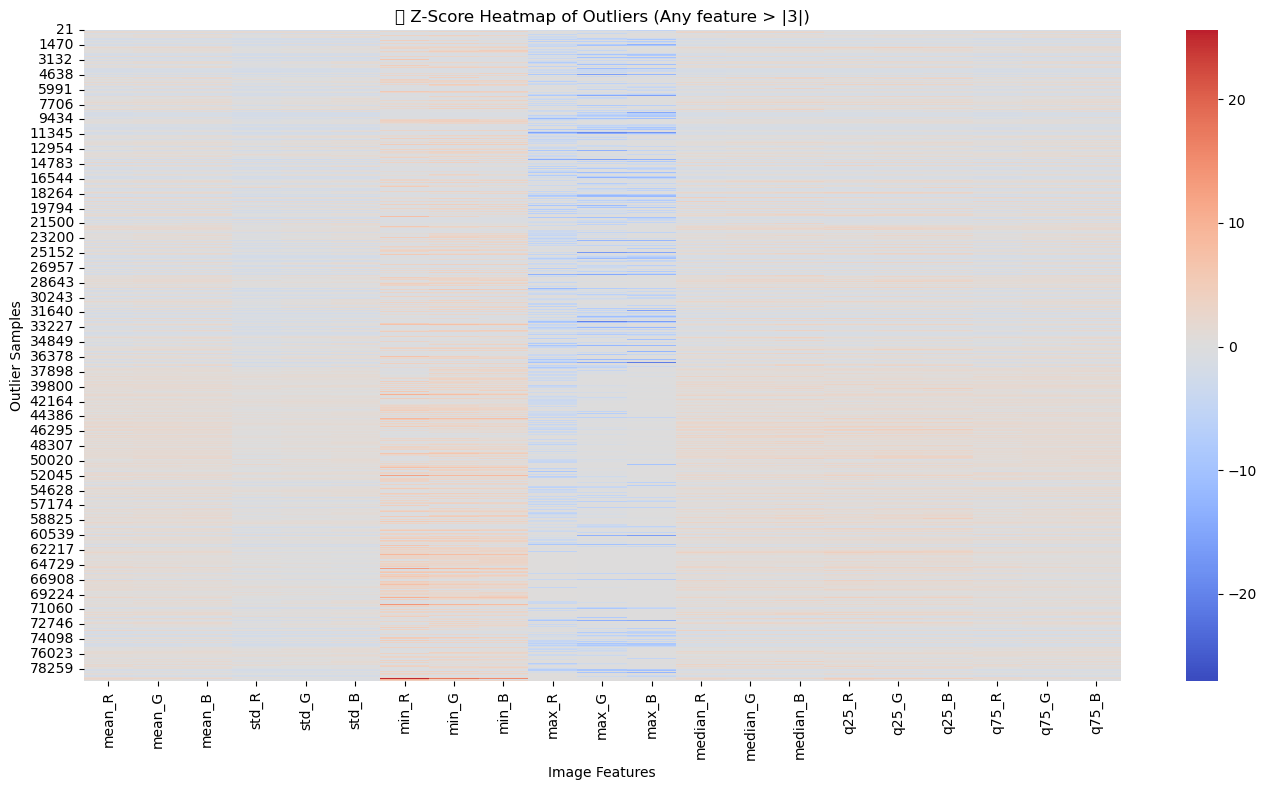

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Load image stats
df = pd.read_csv("image_statistics2.csv")
df.dropna(inplace=True)

# Feature columns (21 total)
feature_cols = [col for col in df.columns if col.startswith(("mean", "std", "min", "max", "median", "q25", "q75"))]

# Compute z-scores
z_scores = pd.DataFrame(zscore(df[feature_cols]), columns=feature_cols)

# Add labels for heatmap row indexing
z_scores["label"] = df["label"]

# Find outliers (any feature's z-score > 3)
outlier_mask = (z_scores[feature_cols].abs() > 3).any(axis=1)

# Extract outlier rows for visualization
z_outliers = z_scores.loc[outlier_mask, feature_cols]

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(z_outliers, cmap="coolwarm", center=0, xticklabels=True)
plt.title("🔍 Z-Score Heatmap of Outliers (Any feature > |3|)")
plt.xlabel("Image Features")
plt.ylabel("Outlier Samples")
plt.tight_layout()
plt.show()
